In [1]:
!pip install ucimlrepo -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Fetch Dermatology dataset
dermatology = fetch_ucirepo(id=33)

# Features
X = dermatology.data.features

# Target
y = dermatology.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (366, 34)
Target shape: (366, 1)


In [4]:
df = pd.concat([X, y], axis=1)

df.head()

,erythema,scaling,definite-borders,itching,koebner phenomenon,polygonal papules,follicular papules,oral-mucosal involvement,knee elbow involvement,scalp involvement,...,disappearance of the granular layer,vacuolisation and damage of the basal layer,spongiosis,saw-tooth appearance of retes,follicular horn plug,perifollicular parakeratosis,inflammatory monoluclear infiltrate,band-like infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [5]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (366, 35)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   erythema                                     366 non-null    int64  
 1   scaling                                      366 non-null    int64  
 2   definite-borders                             366 non-null    int64  
 3   itching                                      366 non-null    int64  
 4   koebner phenomenon                           366 non-null    int64  
 5   polygonal papules                            366 non-null    int64  
 6   follicular papules                           366 non-null    int64  
 7   oral-mucosal involvement                     366 non-null    int64  
 8   knee elbow involvement                       366 non-null    int64  
 9   scalp involvement            

In [6]:
print("Feature names:")
for i, col in enumerate(X.columns, start=1):
    print(i, "-", col)

Feature names:
1 - erythema
2 - scaling
3 - definite-borders
4 - itching
5 - koebner phenomenon
6 - polygonal papules
7 - follicular papules
8 - oral-mucosal involvement
9 - knee elbow involvement
10 - scalp involvement
11 - family history
12 - melanin incontinence
13 - eosinophils in the infiltrate
14 - pnl infiltrate
15 - fibrosis of the papillary dermis
16 - exocytosis
17 - acanthosis
18 - hyperkeratosis
19 - parakeratosis
20 - clubbing of the rete ridges
21 - elongation of the rete ridges
22 - thinning of the suprapapillary epidermis
23 - spongiform pustule
24 - munro microabcess
25 - focal hypergranulosis
26 - disappearance of the granular layer
27 - vacuolisation and damage of the basal layer
28 - spongiosis
29 - saw-tooth appearance of retes
30 - follicular horn plug
31 - perifollicular parakeratosis
32 - inflammatory monoluclear infiltrate
33 - band-like infiltrate
34 - age


In [7]:
print("Mean:")
print(X.mean())

Mean:
erythema                                        2.068306
scaling                                         1.795082
definite-borders                                1.549180
itching                                         1.366120
koebner phenomenon                              0.633880
polygonal papules                               0.448087
follicular papules                              0.166667
oral-mucosal involvement                        0.377049
knee elbow involvement                          0.614754
scalp involvement                               0.519126
family history                                  0.125683
melanin incontinence                            0.404372
eosinophils in the infiltrate                   0.139344
pnl infiltrate                                  0.546448
fibrosis of the papillary dermis                0.336066
exocytosis                                      1.368852
acanthosis                                      1.956284
hyperkeratosis           

In [8]:
print("\nMedian:")
print(X.median())


Median:
erythema                                        2.0
scaling                                         2.0
definite-borders                                2.0
itching                                         1.0
koebner phenomenon                              0.0
polygonal papules                               0.0
follicular papules                              0.0
oral-mucosal involvement                        0.0
knee elbow involvement                          0.0
scalp involvement                               0.0
family history                                  0.0
melanin incontinence                            0.0
eosinophils in the infiltrate                   0.0
pnl infiltrate                                  0.0
fibrosis of the papillary dermis                0.0
exocytosis                                      2.0
acanthosis                                      2.0
hyperkeratosis                                  0.0
parakeratosis                                   1.0
clu

In [9]:
print("\nStandard Deviation:")
print(X.std())


Standard Deviation:
erythema                                        0.664753
scaling                                         0.701527
definite-borders                                0.907525
itching                                         1.138299
koebner phenomenon                              0.908016
polygonal papules                               0.957327
follicular papules                              0.570588
oral-mucosal involvement                        0.834147
knee elbow involvement                          0.982979
scalp involvement                               0.905639
family history                                  0.331946
melanin incontinence                            0.869818
eosinophils in the infiltrate                   0.411790
pnl infiltrate                                  0.815451
fibrosis of the papillary dermis                0.853139
exocytosis                                      1.104418
acanthosis                                      0.712512
hyperkerat

In [10]:
summary_statistics = X.describe().T

summary_statistics

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite-borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral-mucosal involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee elbow involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


In [11]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

age    8
dtype: int64


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 8


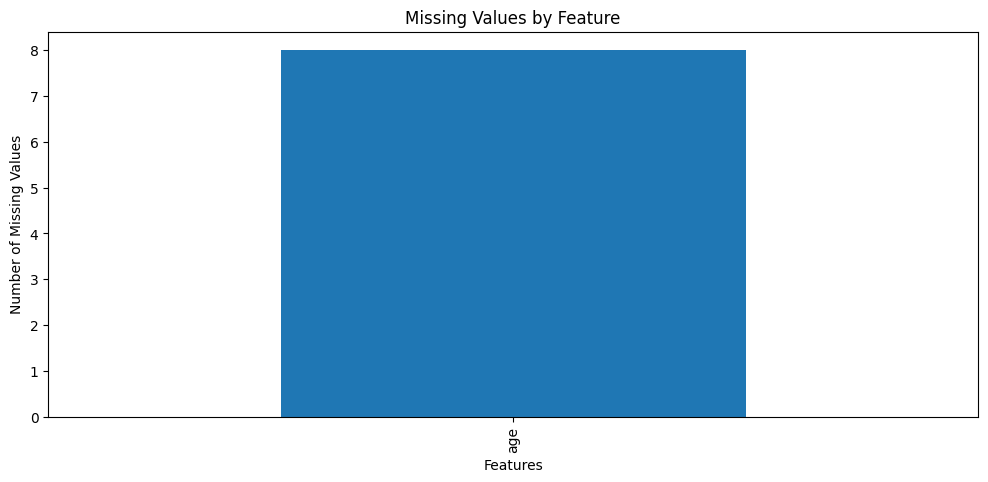

In [13]:
plt.figure(figsize=(12, 5))

missing = df.isnull().sum()

missing[missing > 0].plot(kind='bar')

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.show()

In [14]:
imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values after imputation:")
print(X_imputed.isnull().sum().sum())

Missing values after imputation:
0


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (366, 35)


In [17]:
Q1 = X_imputed.quantile(0.25)
Q3 = X_imputed.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (X_imputed < lower_bound) |
    (X_imputed > upper_bound)
).sum()

print("Outliers by feature:")
print(outlier_count)

Outliers by feature:
erythema                                       151
scaling                                          0
definite-borders                                 0
itching                                          0
koebner phenomenon                              18
polygonal papules                               69
follicular papules                              33
oral-mucosal involvement                        67
knee elbow involvement                          23
scalp involvement                               16
family history                                  46
melanin incontinence                            70
eosinophils in the infiltrate                   42
pnl infiltrate                                   7
fibrosis of the papillary dermis                54
exocytosis                                       0
acanthosis                                     156
hyperkeratosis                                   5
parakeratosis                                    0
clubbing o

In [18]:
print("Total outlier values:", outlier_count.sum())

Total outlier values: 1287


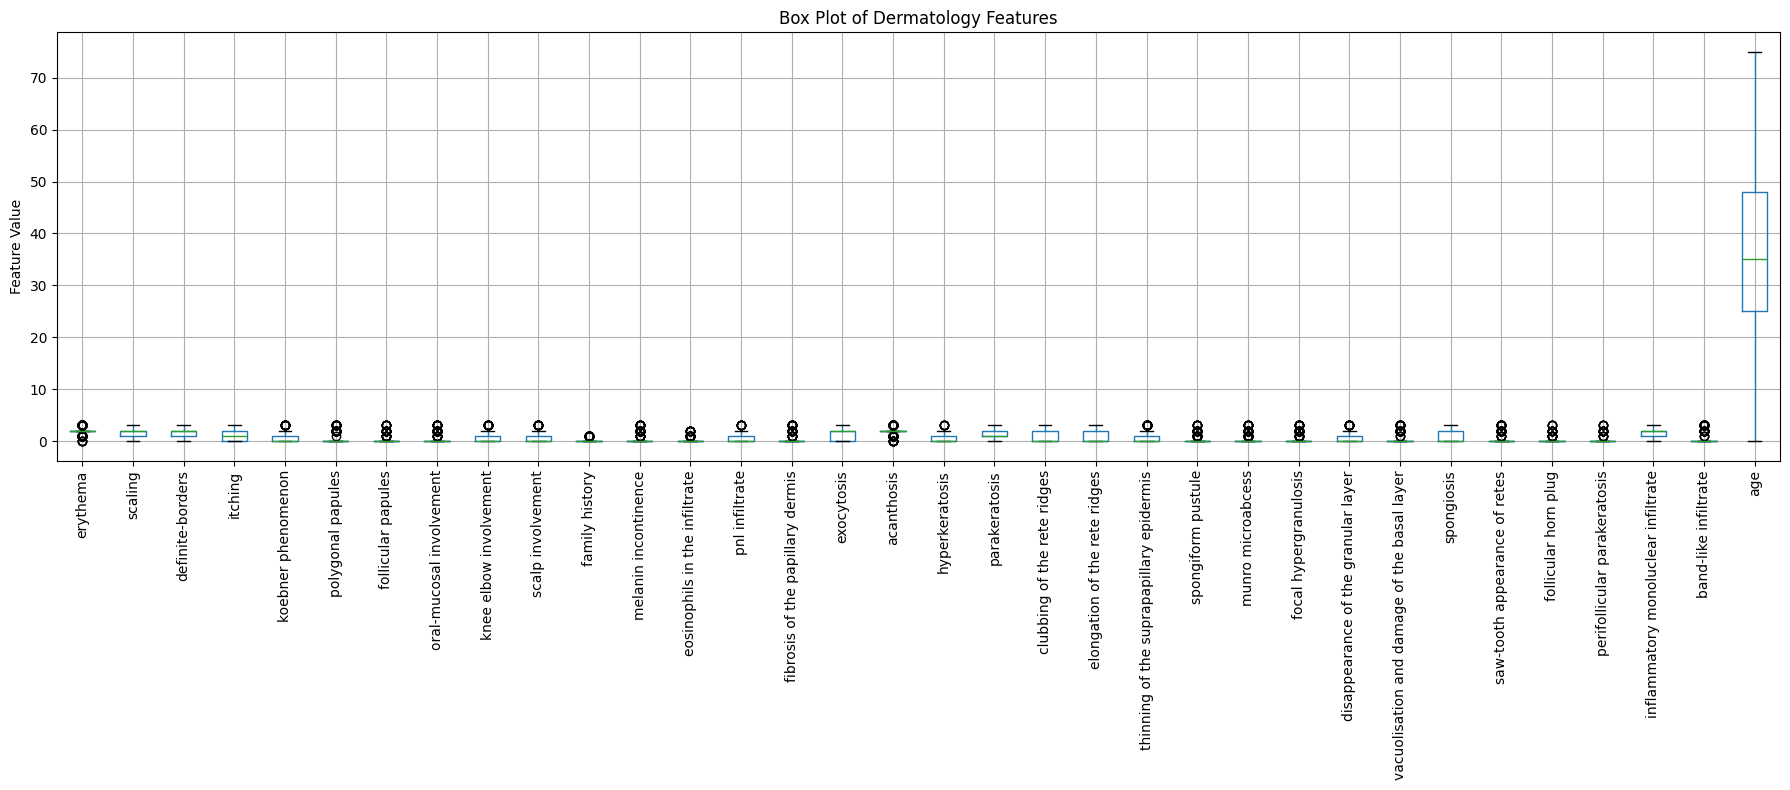

In [19]:
plt.figure(figsize=(18, 8))

X_imputed.boxplot(rot=90)

plt.title("Box Plot of Dermatology Features")
plt.ylabel("Feature Value")
plt.tight_layout()
plt.show()

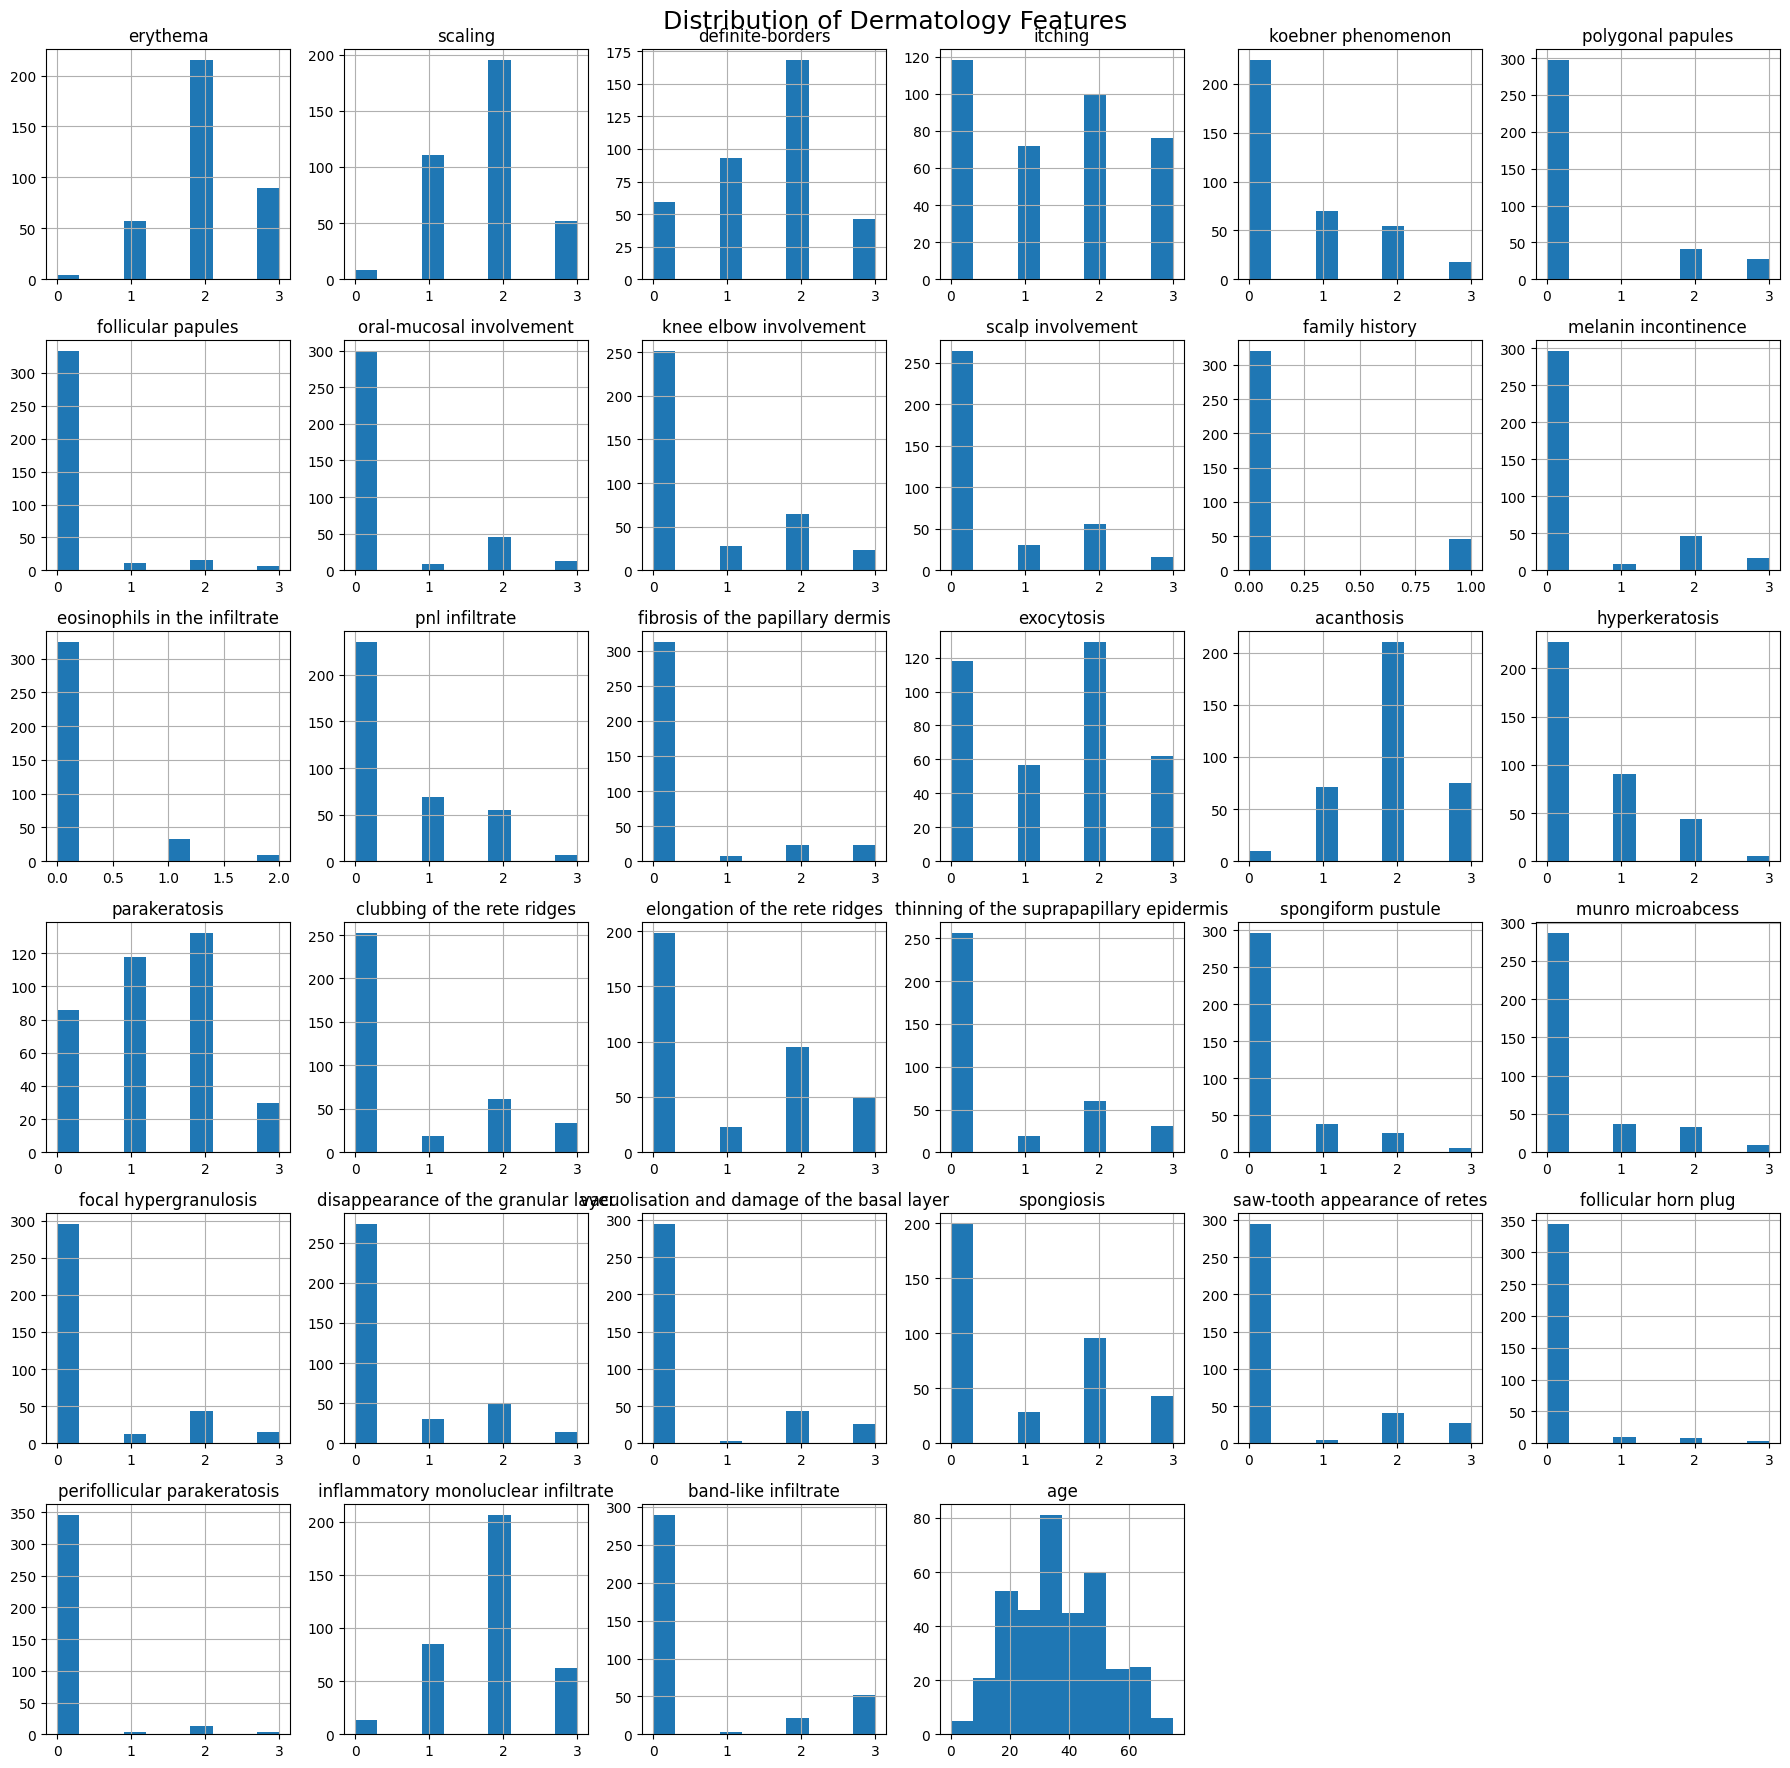

In [20]:
X_imputed.hist(
    figsize=(18, 18),
    bins=10
)

plt.suptitle("Distribution of Dermatology Features", fontsize=18)

plt.tight_layout()
plt.show()

In [21]:
class_names = {
    1: "Psoriasis",
    2: "Seboreic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Cronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

In [22]:
print(y.value_counts().sort_index())

class
1        112
2         61
3         72
4         49
5         52
6         20
Name: count, dtype: int64


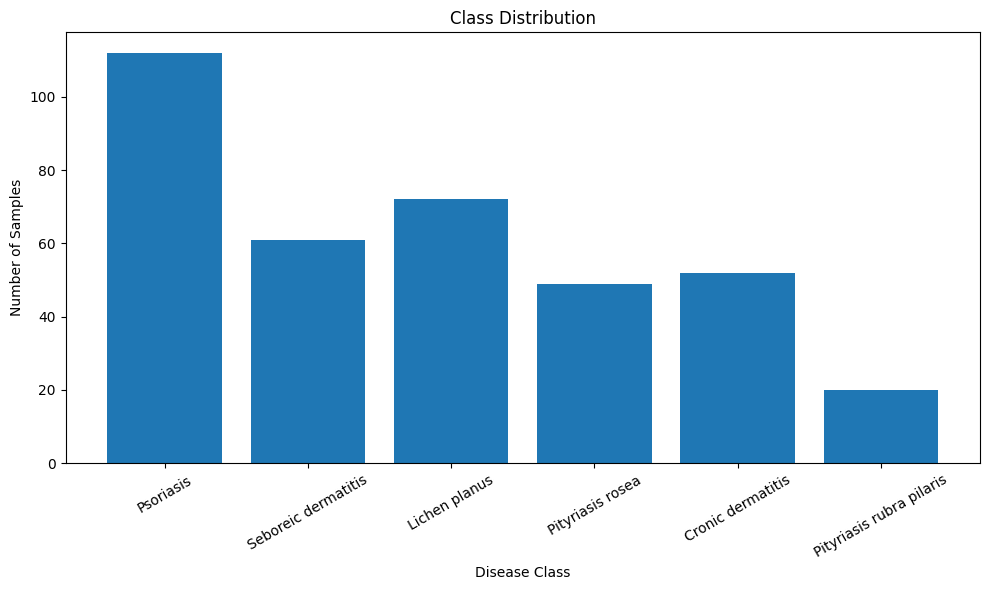

In [23]:
class_counts = y.iloc[:, 0].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values
)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

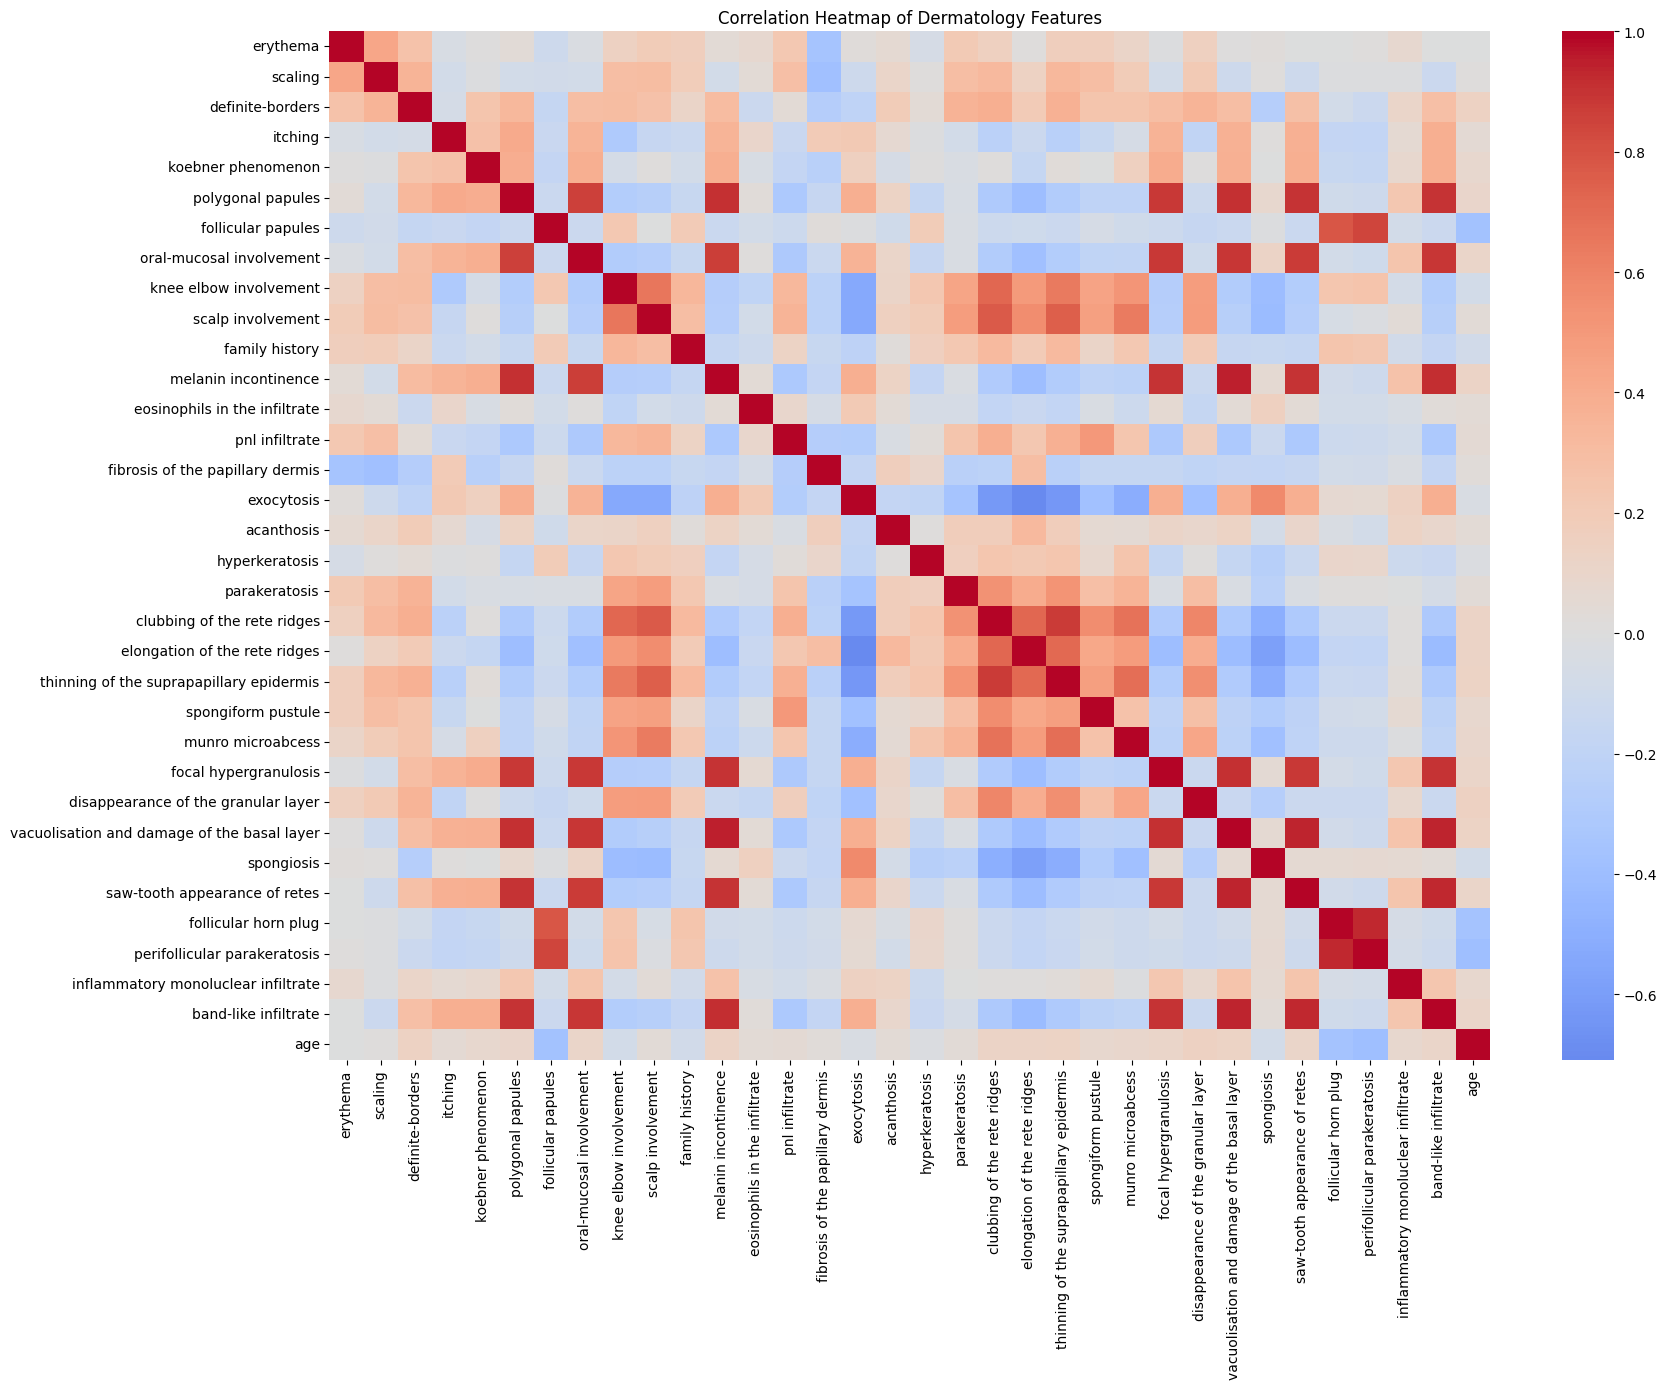

In [24]:
plt.figure(figsize=(18, 14))

correlation_matrix = X_imputed.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Dermatology Features")

plt.tight_layout()
plt.show()

In [25]:
X = X_imputed.copy()

y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (366, 34)
y shape: (366,)


In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))

Original classes: [1 2 3 4 5 6]
Encoded classes: [0 1 2 3 4 5]


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 292
Testing samples: 74


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

In [30]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    print(name, "trained successfully.")

KNN trained successfully.
Logistic Regression trained successfully.
SVM trained successfully.
Random Forest trained successfully.
Decision Tree trained successfully.


In [31]:
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred

    print(name, "prediction completed.")

KNN prediction completed.
Logistic Regression prediction completed.
SVM prediction completed.
Random Forest prediction completed.
Decision Tree prediction completed.


In [32]:
accuracy_results = {}

for name in trained_models:

    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

KNN: 0.9054
Logistic Regression: 0.9595
SVM: 0.9730
Random Forest: 0.9595
Decision Tree: 0.9595


In [33]:
for name in trained_models:

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                class_names[i]
                for i in range(1, 7)
            ],
            zero_division=0
        )
    )


KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
     Seboreic dermatitis       0.80      0.67      0.73        12
           Lichen planus       1.00      0.93      0.97        15
        Pityriasis rosea       0.64      0.90      0.75        10
       Cronic dermatitis       1.00      1.00      1.00        10
Pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.91        74
               macro avg       0.91      0.91      0.90        74
            weighted avg       0.92      0.91      0.91        74


Logistic Regression
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
     Seboreic dermatitis       1.00      0.83      0.91        12
           Lichen planus       1.00      0.93      0.97        15
        Pityriasis rosea       0.77      1.00 

In [34]:
results = []

for name in trained_models:

    y_pred = predictions[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.905405,0.919305,0.905405,0.908094
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642
2,SVM,0.972973,0.977477,0.972973,0.972973
3,Random Forest,0.959459,0.960688,0.959459,0.959543
4,Decision Tree,0.959459,0.964619,0.959459,0.959392


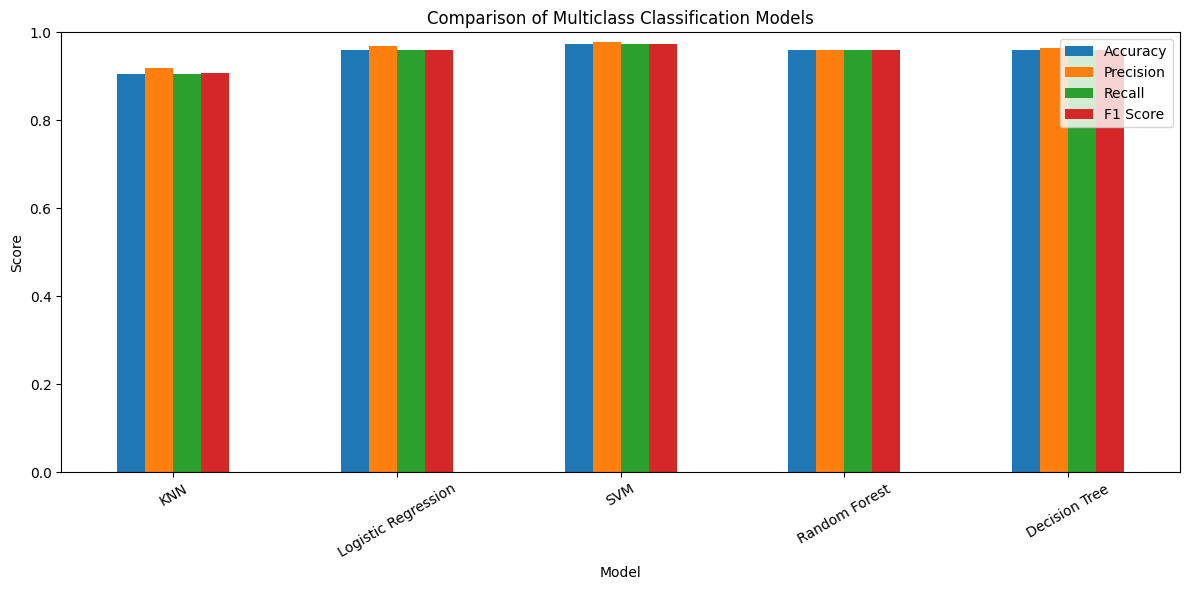

In [35]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Multiclass Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

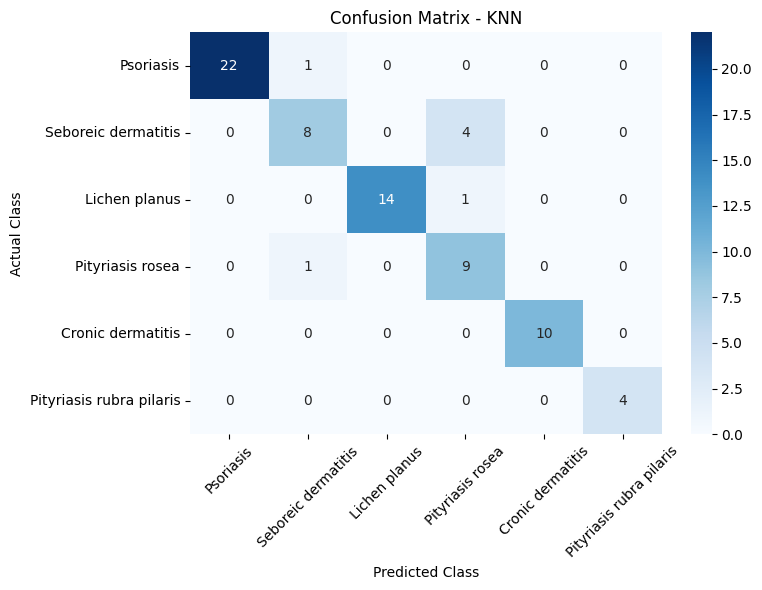

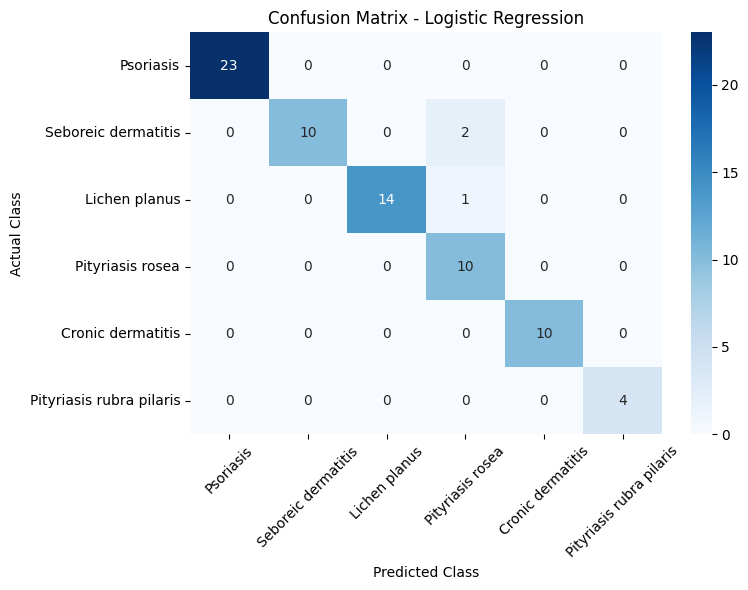

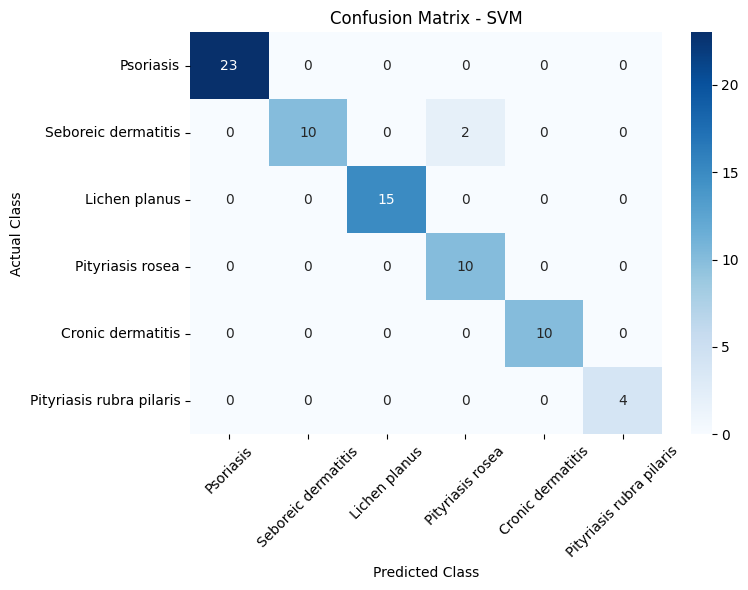

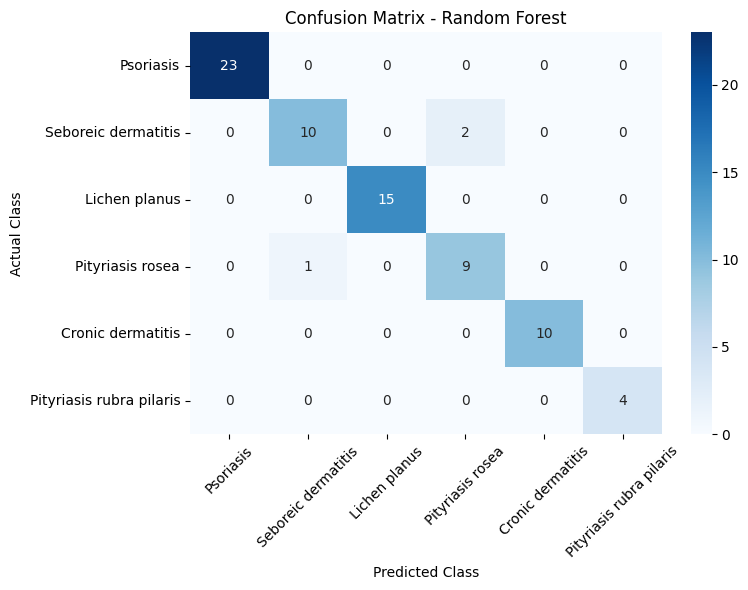

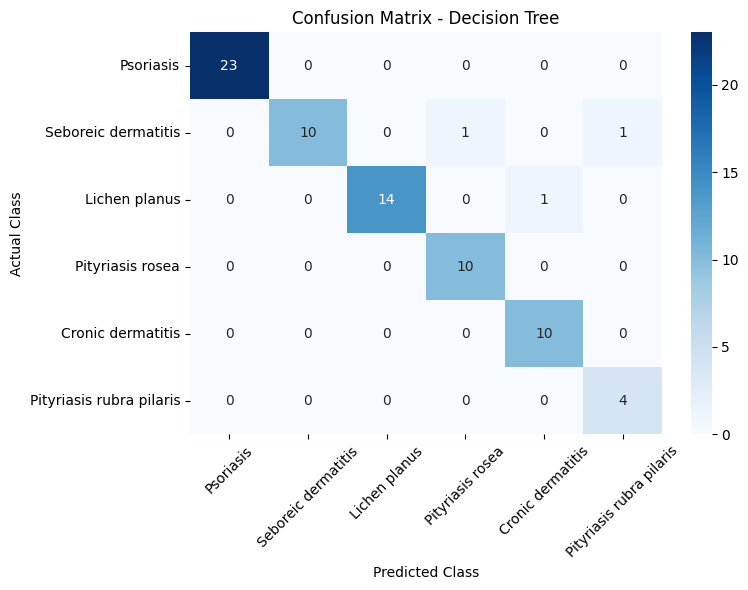

In [36]:
for name in trained_models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            class_names[i]
            for i in range(1, 7)
        ],
        yticklabels=[
            class_names[i]
            for i in range(1, 7)
        ]
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [37]:
n_classes = 6

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

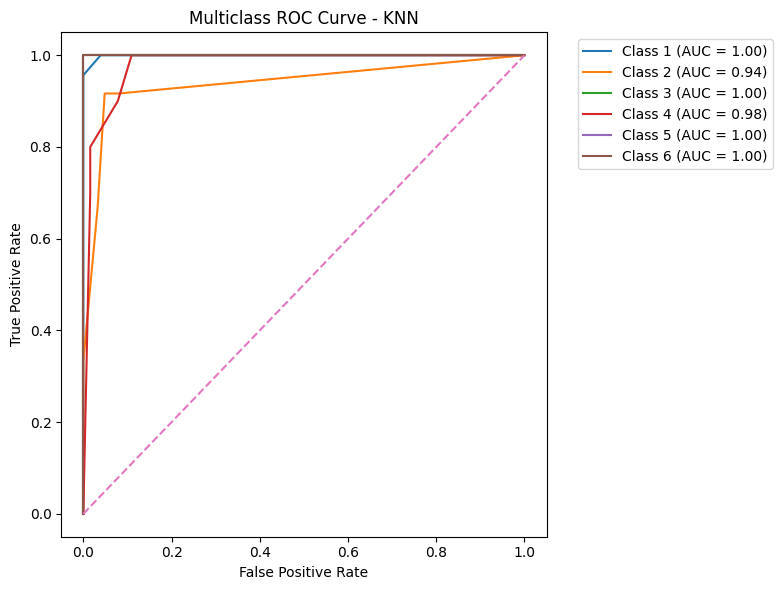

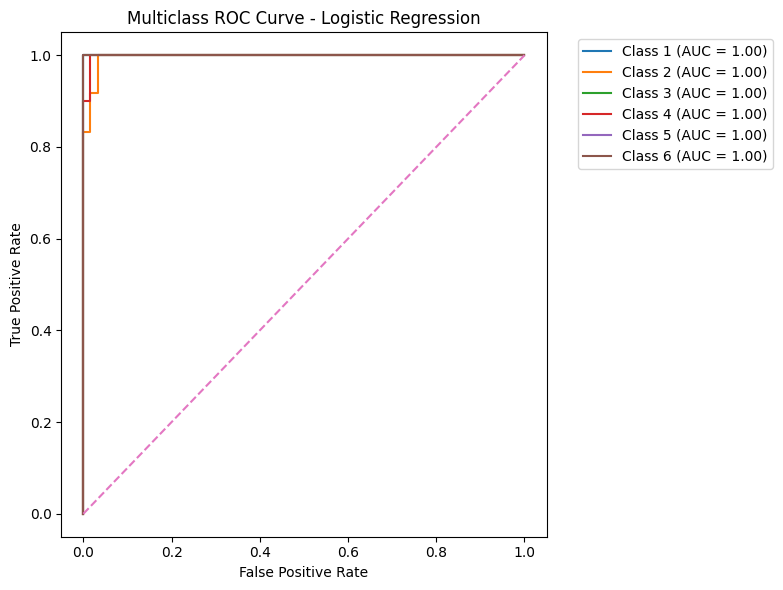

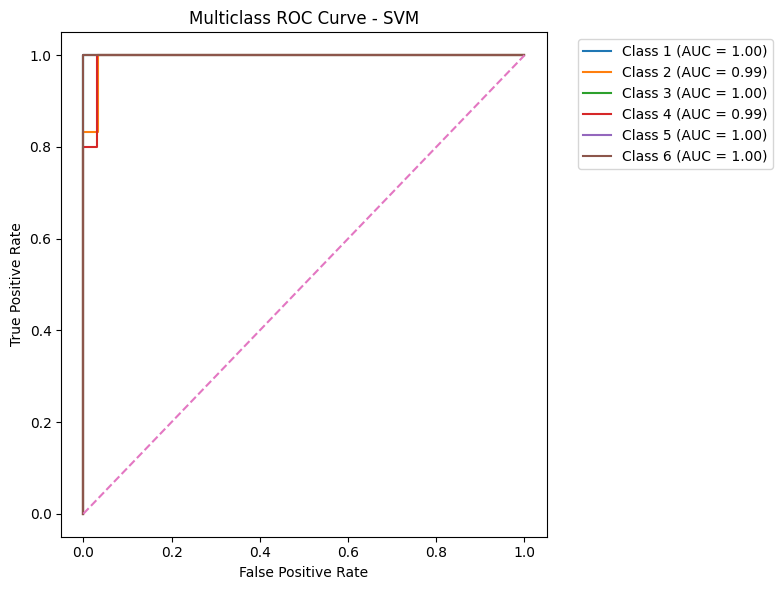

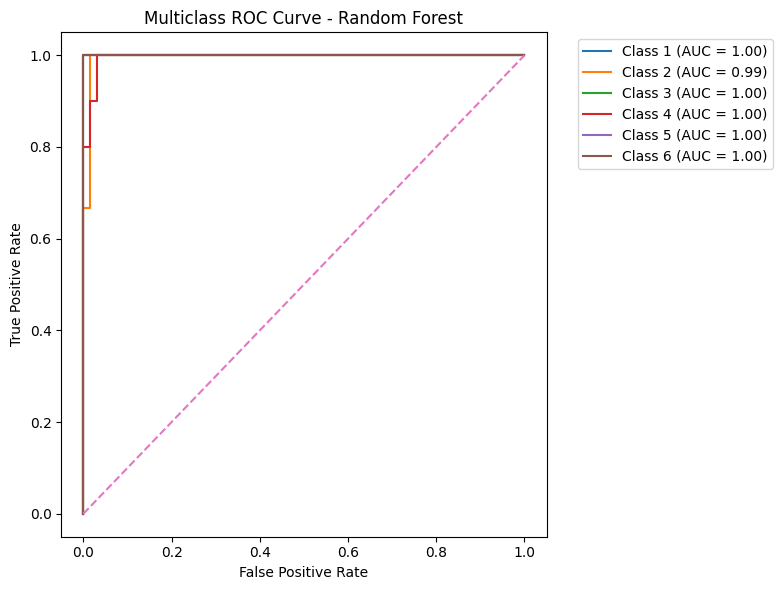

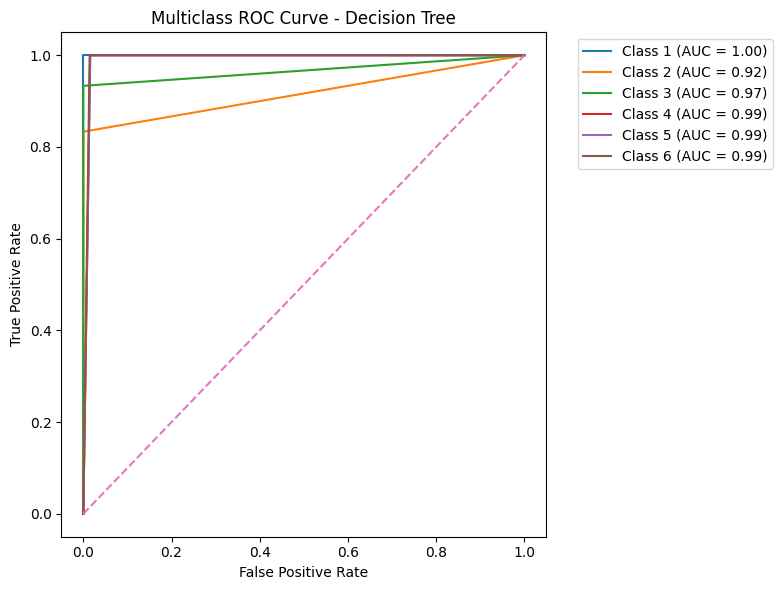

In [38]:
for name, model in trained_models.items():

    y_score = model.predict_proba(X_test_scaled)

    plt.figure(figsize=(8, 6))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"Class {i+1} (AUC = {roc_auc:.2f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"Multiclass ROC Curve - {name}")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [39]:
auc_results = {}

for name, model in trained_models.items():

    y_score = model.predict_proba(X_test_scaled)

    auc_score = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class="ovr",
        average="weighted"
    )

    auc_results[name] = auc_score

    print(
        f"{name}: Weighted Multiclass AUC = "
        f"{auc_score:.4f}"
    )

KNN: Weighted Multiclass AUC = 0.9871
Logistic Regression: Weighted Multiclass AUC = 0.9991
SVM: Weighted Multiclass AUC = 0.9983
Random Forest: Weighted Multiclass AUC = 0.9985
Decision Tree: Weighted Multiclass AUC = 0.9772


In [40]:
results_df["AUC"] = results_df["Model"].map(
    auc_results
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,KNN,0.905405,0.919305,0.905405,0.908094,0.987076
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.999135
2,SVM,0.972973,0.977477,0.972973,0.972973,0.998284
3,Random Forest,0.959459,0.960688,0.959459,0.959543,0.998495
4,Decision Tree,0.959459,0.964619,0.959459,0.959392,0.977232


In [41]:
final_results = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
2,SVM,0.972973,0.977477,0.972973,0.972973,0.998284
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.999135
3,Random Forest,0.959459,0.960688,0.959459,0.959543,0.998495
4,Decision Tree,0.959459,0.964619,0.959459,0.959392,0.977232
0,KNN,0.905405,0.919305,0.905405,0.908094,0.987076
